# **Sub-hypothesis Nr. n:**

Despite regulatory measures, the total TRI (Toxics Release Inventory - chemicals that may pose a threat to human health and the environment) pounds of hazardous chemicals released annually have not significantly decreased over time.

*Author: Anna Korostelyova*

## Objectives
1. Analyze trends in the total TRI pounds of hazardous chemicals over time.
2. Determine whether there is a statistically significant decrease in chemical emissions.
3. Identify key contributors (chemicals) to total emissions.

## Calculations

In [ ]:
pip install mysql.connector-python

In [36]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.stats import pearsonr

Let's create several functions:

In [106]:
def calculate_annual_totals(data, year_column, value_column):
    return data.groupby(year_column)[value_column].sum()

def calculate_correlation(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sqrt(np.sum((x - mean_x)**2) * np.sum((y - mean_y)**2))
    return numerator / denominator

Let's upload data from excel file:

In [12]:
file_path = r"C:\Users\User\Downloads\CP project - chemicals\chemicals.xlsx" 
sheet_name = 'Sheet1' 
data = pd.read_excel(file_path, sheet_name=sheet_name)

mydb = mysql.connector.connect(
)

cursor = mydb.cursor()

my_table = '''
CREATE TABLE IF NOT EXISTS chemicals5 (
    Submission_Year INT NOT NULL,
    TRI_Facility_ID VARCHAR(255) NOT NULL,
    TRI_Facility_Name VARCHAR(255) NOT NULL,
    Chemical VARCHAR(900) NOT NULL,
    TRI_Pounds DECIMAL(38, 2) NOT NULL,
    RSEI_Hazard DECIMAL(38, 2),
    RSEI_Hazard_Cancer DECIMAL(38, 2)
);
'''

cursor.execute(my_table)

insert_query = '''
INSERT INTO chemicals5 (
    Submission_Year,
    TRI_Facility_ID,
    TRI_Facility_Name,
    Chemical,
    TRI_Pounds,
    RSEI_Hazard,
    RSEI_Hazard_Cancer
) VALUES (%s, %s, %s, %s, %s, %s, %s)
'''

for _, row in data.iterrows():
    cursor.execute(insert_query, tuple(row))

mydb.commit()

chem_df = pd.read_sql('SELECT * FROM chemicals5', con=mydb)

cursor.close()
mydb.close()

C:\Users\User\AppData\Local\Temp\ipykernel_7584\777465434.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chem_df = pd.read_sql('SELECT * FROM chemicals5', con=mydb)


In [16]:
chem_df

,Submission_Year,TRI_Facility_ID,TRI_Facility_Name,Chemical,TRI_Pounds,RSEI_Hazard,RSEI_Hazard_Cancer
0,2014,99752RDDGP90MIL,RED DOG OPERATIONS,Zinc and zinc compounds,6.780574e+08,2.240521e+09,0.000000e+00
1,2017,99752RDDGP90MIL,RED DOG OPERATIONS,Lead and lead compounds,6.084076e+08,1.095144e+13,5.171295e+12
2,2013,99752RDDGP90MIL,RED DOG OPERATIONS,Zinc and zinc compounds,5.315991e+08,1.755833e+09,0.000000e+00
3,2018,99752RDDGP90MIL,RED DOG OPERATIONS,Lead and lead compounds,4.904514e+08,8.828216e+12,4.168682e+12
4,2017,99752RDDGP90MIL,RED DOG OPERATIONS,Zinc and zinc compounds,4.515548e+08,1.492525e+09,0.000000e+00
...,...,...,...,...,...,...,...
720498,2022,99752RDDGP90MIL,RED DOG OPERATIONS,n-Hexane,0.000000e+00,0.000000e+00,0.000000e+00
720499,2022,99801KNNCT13401,HECLA GREENS CREEK MINING CO,"1,2,4-Trimethylbenzene",0.000000e+00,0.000000e+00,0.000000e+00
720500,2022,99801KNNCT13401,HECLA GREENS CREEK MINING CO,Naphthalene,0.000000e+00,0.000000e+00,0.000000e+00
720501,2022,99801KNNCT13401,HECLA GREENS CREEK MINING CO,Xylene (mixed isomers),0.000000e+00,0.000000e+00,0.000000e+00


In [18]:
annual_totals = {}
for year in chem_df['Submission_Year'].unique():
    annual_totals[year] = chem_df[chem_df['Submission_Year'] == year]['TRI_Pounds'].sum()

print(annual_totals)

{2014: 7312108340.49, 2017: 7374182888.760001, 2013: 7446952916.44, 2018: 7224939017.270002, 2016: 6928841271.360001, 2019: 6765361404.930003, 2020: 6184143105.360002, 2021: 6528811479.799998, 2022: 6512356228.870001, 2015: 7049344379.310001}


In [20]:
values = np.array(list(annual_totals.values()))
mean_emissions = np.mean(values)
std_emissions = np.std(values)

print(f"Average amount of Emissions from 2013 to 2022: {mean_emissions}")
print(f"Standard Deviation of Emissions: {std_emissions}")

Average amount of Emissions from 2013 to 2022: 6932704103.259001
Standard Deviation of Emissions: 403793609.23823607


## Trends in the total TRI pounds of hazardous chemicals over time

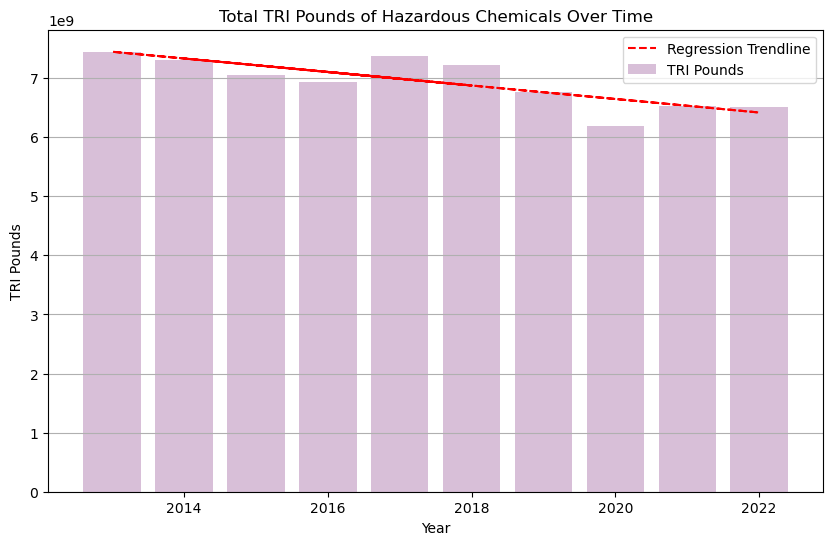

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     15.60
Date:                Sat, 28 Dec 2024   Prob (F-statistic):            0.00423
Time:                        15:30:06   Log-Likelihood:                -206.94
No. Observations:                  10   AIC:                             417.9
Df Residuals:                       8   BIC:                             418.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.375e+11   5.84e+10      4.069      0.0

C:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


In [192]:
years = list(annual_totals.keys())
values = list(annual_totals.values())

years_numeric = np.array(years)
values_numeric = np.array(values)

X = sm.add_constant(years_numeric)

model = sm.OLS(values_numeric, X).fit()

regression_line = model.predict(X)

plt.figure(figsize=(10, 6))
plt.bar(years, values, color='thistle', label='TRI Pounds')
plt.plot(years, regression_line, color='red', linestyle='--', label='Regression Trendline')
plt.title('Total TRI Pounds of Hazardous Chemicals Over Time')
plt.xlabel('Year')
plt.ylabel('TRI Pounds')
plt.legend()
plt.grid(axis='y')
plt.show()

print(model.summary())

# Statistical significance:

In [111]:
correlation, p_value = pearsonr(years_numeric, values_numeric)

print(f"Correlation Coefficient: {correlation}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Correlation Coefficient: -0.8130709719616604
P-Value: 0.004234365494421618
The correlation is statistically significant.


Pearson correlation coefficient, calculated using the formula, to verify the accuracy of Python modules in computing it:

In [54]:
calculate_correlation(years, values)

-0.8130709719616604

## Key contributors (chemicals) to total emissions

Top Contributors to Total Emissions:
Chemical
Zinc and zinc compounds                  1.217306e+10
Lead and lead compounds                  9.085793e+09
Copper and copper compounds              6.734419e+09
Manganese and manganese compounds        4.610628e+09
Nitrate compounds (water dissociable)    4.067036e+09
Methanol                                 3.490523e+09
Chromium and chromium compounds          2.864388e+09
Arsenic and arsenic compounds            2.619844e+09
Nickel and nickel compounds              2.357143e+09
Barium and barium compounds              2.178997e+09
Name: TRI Pounds, dtype: float64


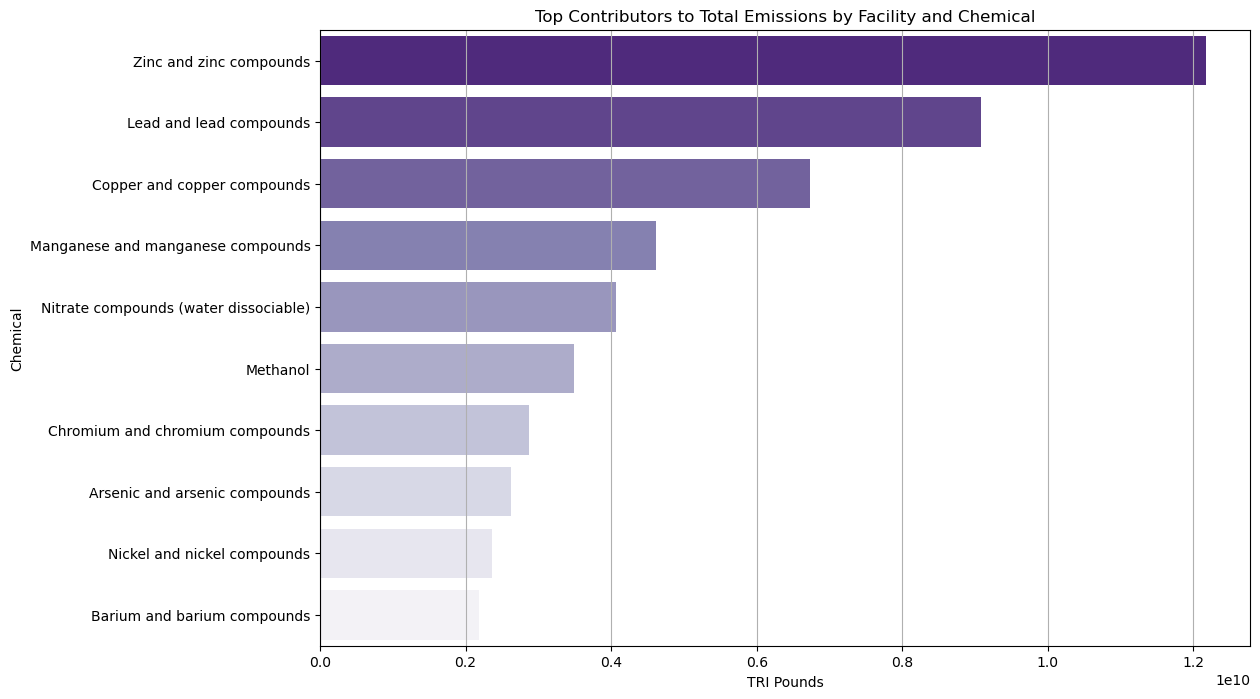

In [180]:
contributors = data.groupby('Chemical')['TRI Pounds'].sum()
contributors = contributors.sort_values(ascending=False)

print("Top Contributors to Total Emissions:")
print(contributors.head(10))

top_contributors = contributors.head(10).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(
    x='TRI Pounds', 
    y='Chemical',  
    data=top_contributors, 
    dodge=False,
    hue='Chemical',
    palette='Purples_r'
)
plt.title('Top Contributors to Total Emissions by Facility and Chemical')
plt.xlabel('TRI Pounds')
plt.ylabel('Chemical')
plt.grid(axis='x')
plt.show()

## Conclusions

The regression analysis and correlation test indicate a statistically significant decrease in the total TRI pounds of hazardous chemicals released annually over time. However, a small number of chemicals still make up most of the emissions, so efforts should focus on reducing these specific chemicals to continue the progress.